<a href="https://colab.research.google.com/github/nimraa9090/AI-projects/blob/main/lab09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

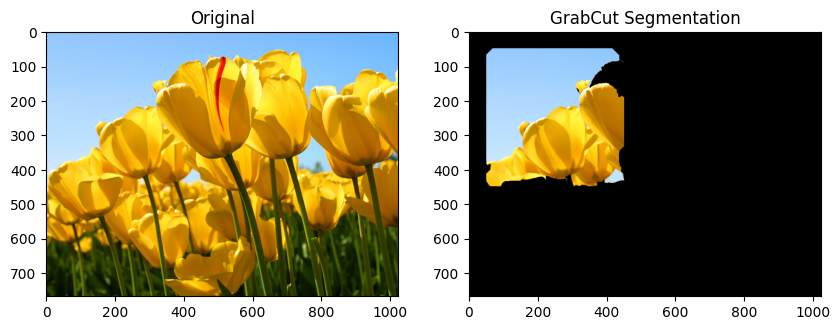

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread("test.jpg")
mask = np.zeros(img.shape[:2], np.uint8)

# Define the region of interest (x, y, width, height)
# You may need to adjust these coordinates based on your image
rect = (50, 50, 400, 400)

# Arrays used by the algorithm internally
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

# Apply GrabCut
cv2.grabCut(img, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

# Create a binary mask where 0 and 2 are background, 1 and 3 are foreground
mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')
img_cut = img * mask2[:, :, np.newaxis]

# Display
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("Original")
plt.subplot(1, 2, 2); plt.imshow(cv2.cvtColor(img_cut, cv2.COLOR_BGR2RGB)); plt.title("GrabCut Segmentation")
plt.show()

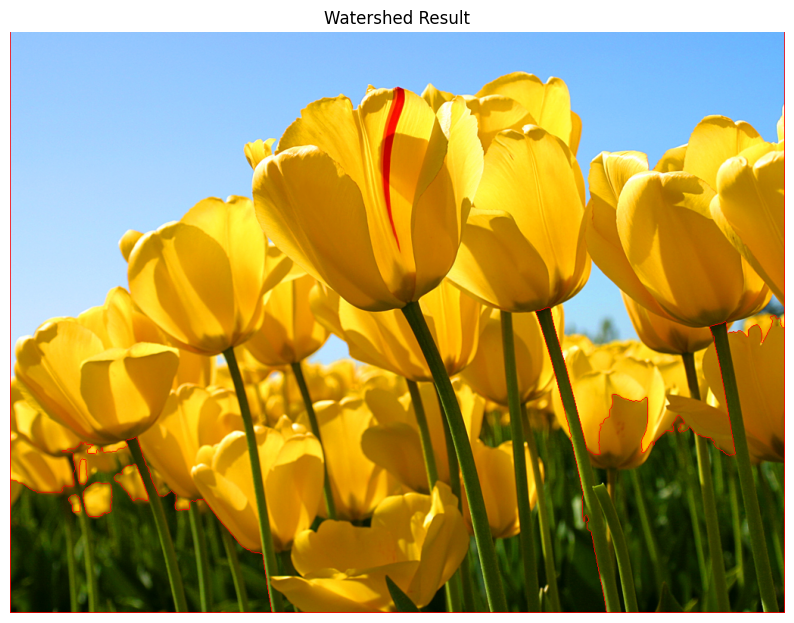

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load image
img = cv2.imread("test.jpg")
if img is None:
    raise FileNotFoundError("test.jpg not found.")

# 2. Convert to Grayscale and Threshold
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 3. Create Distance Transform
# We use this to identify the "center" of objects
dist_transform = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)

# 4. Find the "Sure Foreground" (The centers of your objects)
# We use a small percentage of the max distance to avoid noise
ret, sure_fg = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, cv2.THRESH_BINARY)
sure_fg = np.uint8(sure_fg)

# 5. Find the "Sure Background" (The area we know is definitely NOT the object)
sure_bg = cv2.dilate(thresh, np.ones((3,3), np.uint8), iterations=3)

# 6. Find the "Unknown" region
# This is where the watershed algorithm will do its work
unknown = cv2.subtract(sure_bg, sure_fg)

# 7. Create Markers
# This is the most critical step. If this is empty, your output will just be the original image.
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1 # Background is 1, objects start at 2
markers[unknown == 255] = 0 # Unknown is 0

# 8. Apply Watershed
# We pass the original image (img) and the markers
markers = cv2.watershed(img, markers)

# 9. Draw the result
# The watershed algorithm sets boundary pixels to -1
img[markers == -1] = [0, 0, 255] # Red borders

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Watershed Result")
plt.axis('off')
plt.show()